In [1]:
# Test 1: Import key libraries
import pandas as pd
import boto3
import numpy as np

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Test 2: Connect to S3
s3 = boto3.client('s3')
response = s3.list_buckets()
bucket_count = len(response['Buckets'])

print(f"Connected to S3")
print(f"Found {bucket_count} S3 buckets")

# Print your buckets (to identify your modeling data bucket)
for bucket in response['Buckets']:
    print(f"  - {bucket['Name']}")

Connected to S3
Found 1 S3 buckets
  - cmse492-mcconv15-nyc311-891376917256-us-east-1-an


In [7]:
response = s3.list_objects_v2(Bucket=bucket_name, Prefix='modeling/')

if 'Contents' in response:
    print("Files found in S3:")
    for obj in response['Contents']:
        print(f"- {obj['Key']}")
else:
    print("The folder 'modeling/' is empty or doesn't exist.")

Files found in S3:
- modeling/
- modeling/complaint_type_modeling/
- modeling/complaint_type_modeling/modeling_data.csv
- modeling/ll-multiclass/output/linear-learner-2026-04-19-21-51-00-647/debug-output/training_job_end.ts
- modeling/ll-multiclass/output/linear-learner-2026-04-19-21-51-00-647/output/model.tar.gz
- modeling/ll-multiclass/output/linear-learner-2026-04-19-21-51-00-647/profiler-output/framework/training_job_end.ts
- modeling/ll-multiclass/output/linear-learner-2026-04-19-21-51-00-647/profiler-output/system/incremental/2026041921/1776635460.algo-1.json
- modeling/ll-multiclass/output/linear-learner-2026-04-19-21-51-00-647/profiler-output/system/incremental/2026041921/1776635520.algo-1.json
- modeling/ll-multiclass/output/linear-learner-2026-04-19-21-51-00-647/profiler-output/system/incremental/2026041921/1776635580.algo-1.json
- modeling/ll-multiclass/output/linear-learner-2026-04-19-21-51-00-647/profiler-output/system/incremental/2026041921/1776635640.algo-1.json
- modeli

In [8]:
s3 = boto3.client('s3')
bucket_name = 'cmse492-mcconv15-nyc311-891376917256-us-east-1-an' # replace with your bucket name (make sure you have the account regional suffix)
file_name = 'modeling/complaint_type_modeling/modeling_data.csv' 

obj = s3.get_object(Bucket=bucket_name, Key=file_name)
data = obj['Body'].read().decode('utf-8')
df = pd.read_csv(StringIO(data))

print(f"Shape: {df.shape}")
df.head()

Shape: (173851, 8)


,agency,borough,problem,incident_zip,day_of_week,hour_of_day,same_day_complaint_volume,days_to_close
0,DCWP,MANHATTAN,Consumer Complaint,10019.0,6,11,17,31
1,DCWP,BROOKLYN,Consumer Complaint,11220.0,6,16,17,31
2,DCWP,QUEENS,Consumer Complaint,11432.0,6,11,17,1
3,DCWP,MANHATTAN,Consumer Complaint,10280.0,6,12,17,31
4,DCWP,QUEENS,Consumer Complaint,11358.0,6,16,17,1


In [9]:
# First few rows
print("First few rows:")
print(df.head())

# Data types and missing values
print("\n" + "="*50)
print("Data types and missing values:")
print(df.info())

First few rows:
  agency    borough             problem  incident_zip  day_of_week  \
0   DCWP  MANHATTAN  Consumer Complaint       10019.0            6   
1   DCWP   BROOKLYN  Consumer Complaint       11220.0            6   
2   DCWP     QUEENS  Consumer Complaint       11432.0            6   
3   DCWP  MANHATTAN  Consumer Complaint       10280.0            6   
4   DCWP     QUEENS  Consumer Complaint       11358.0            6   

   hour_of_day  same_day_complaint_volume  days_to_close  
0           11                         17             31  
1           16                         17             31  
2           11                         17              1  
3           12                         17             31  
4           16                         17              1  

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173851 entries, 0 to 173850
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype  
---  -----

In [10]:
# Summary statistics
print("Summary statistics:")
print(df.describe())

Summary statistics:
        incident_zip    day_of_week    hour_of_day  same_day_complaint_volume  \
count  172086.000000  173851.000000  173851.000000              173851.000000   
mean    10838.974629       3.898614      13.006040                 437.072085   
std       528.743746       1.990228       6.034949                 647.101016   
min     10000.000000       1.000000       0.000000                   1.000000   
25%     10452.000000       2.000000       9.000000                  51.000000   
50%     11205.000000       4.000000      13.000000                 260.000000   
75%     11235.000000       6.000000      18.000000                 559.000000   
max     11697.000000       7.000000      23.000000                3759.000000   

       days_to_close  
count  173851.000000  
mean        2.061656  
std         5.120339  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         2.000000  
max        49.000000  


Target distribution (problem):
problem
Illegal Parking                  28835
HEAT/HOT WATER                   28232
Noise - Residential              16623
Snow or Ice                      11846
Blocked Driveway                 11033
Street Condition                  6479
Traffic Signal Condition          5415
Noise - Street/Sidewalk           3570
Water System                      3568
Dirty Condition                   3359
PLUMBING                          3279
UNSANITARY CONDITION              3162
Abandoned Vehicle                 2827
PAINT/PLASTER                     2381
Noise                             2327
Noise - Commercial                2274
Noise - Vehicle                   1702
WATER LEAK                        1616
General Construction/Plumbing     1499
DOOR/WINDOW                       1476
Derelict Vehicles                 1454
Elevator                          1310
Damaged Tree                      1289
ELECTRIC                          1249
Illegal Dumping          

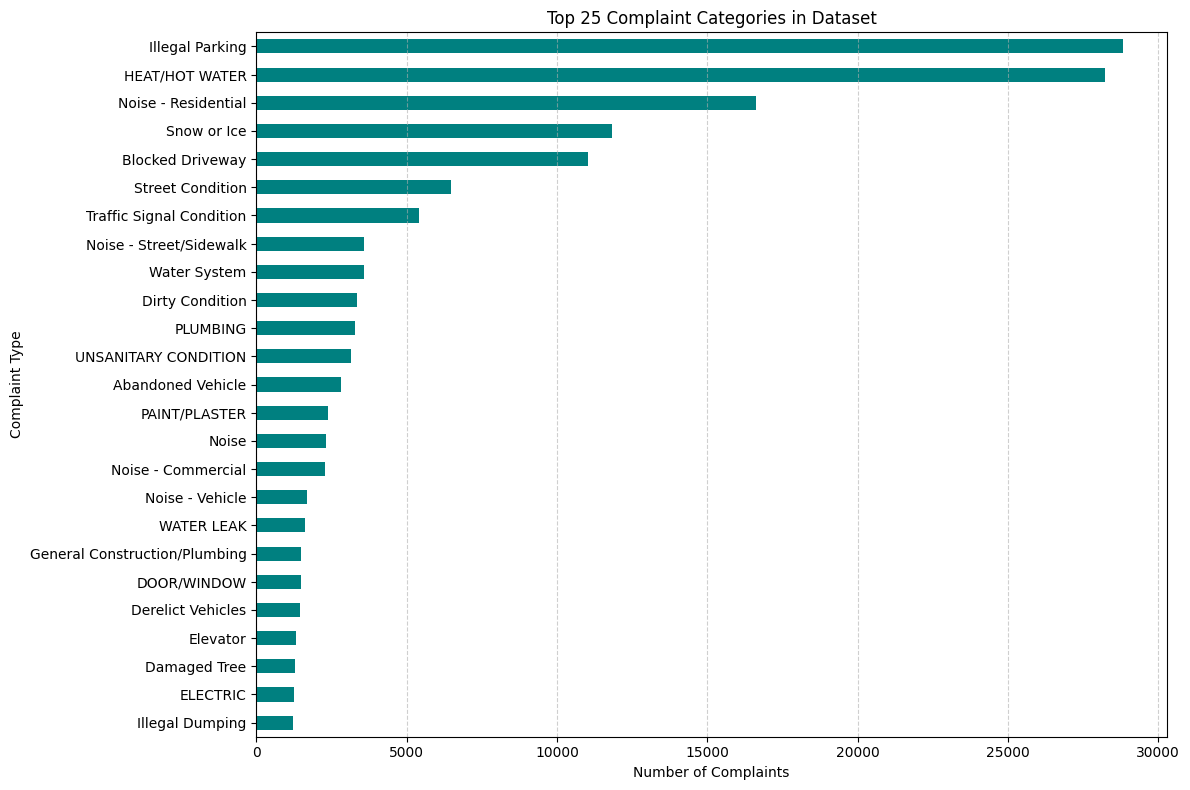

In [17]:
## utilized Google's Gemini to generate the code for this cell

# 1. Update this to match your actual target column from your SQL query
target_col = 'problem' 

# Check target balance
print(f"Target distribution ({target_col}):")
# head(25) keeps the printout manageable too
print(df[target_col].value_counts().head(25))

# As percentage
print(f"\nTarget distribution (%) for {target_col}:")
print((df[target_col].value_counts(normalize=True) * 100).round(2).head(25))

# 2. Visualize the Top 25
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
# head(25) limits the bars on the y-axis
df[target_col].value_counts().head(25).plot(kind='barh', color='teal')

plt.title(f'Top 25 Complaint Categories in Dataset')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.gca().invert_yaxis() # Biggest bars at the top
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
# Balance check based on the example query, the target variable is `volume_quartile` -- make sure you're checking the right target variable for your modeling table!

# Check target balance
print("Target distribution (problem):")
print(df['problem'].value_counts().sort_index())

# As percentage
print("\nTarget distribution (%)")
print((df['problem'].value_counts() / len(df) * 100).sort_index().round(2))

Target distribution (problem):
problem
AHV Inspection Unit       2
APPLIANCE               641
Abandoned Bike           55
Abandoned Vehicle      2827
Air Quality             346
                       ... 
Water Conservation      781
Water Quality            42
Water System           3568
Wayfinding                1
Wood Pile Remaining      57
Name: count, Length: 147, dtype: int64

Target distribution (%)
problem
AHV Inspection Unit    0.00
APPLIANCE              0.37
Abandoned Bike         0.03
Abandoned Vehicle      1.63
Air Quality            0.20
                       ... 
Water Conservation     0.45
Water Quality          0.02
Water System           2.05
Wayfinding             0.00
Wood Pile Remaining    0.03
Name: count, Length: 147, dtype: float64
